# A Case study on RandomForest
Maintaining a healthy diet and lifestyle is essential for preventing obesity and other health-related issues. Healthcare professionals and nutritionists often need to assess an individual's health condition based on dietary habits, calorie intake, BMI, and physical activity.

**Source link of data**-->https://www.kaggle.com/datasets/aliyasaly1231/healthy-diet-and-calorie-intake?resource=download

And the  dataset is ***Classification problem*** and the objective of this project is to build a Machine Learning model using ***Random Forest*** to predict an individual's **health status** based on **demographic**, **dietary**, and **lifestyle factors**.

### Data Dictionary
**Person_ID**
Unique identifier for each individual (e.g. P0001). Not a predictive feature.

**Age**
Age of the individual in years across multiple life stages.

**Gender**
Gender of the individual — Male, Female, or Other.

**Height_cm**
Height measured in centimeters. Used to calculate BMI.

**Weight_kg**
Body weight in kilograms. Key metric for health assessment.

**BMI**
Body Mass Index = weight(kg) / height(m)². Indicates Healthy, Overweight, Obese or Underweight.

**Activity_Level**
Physical activity level — Sedentary, Lightly Active, Moderately Active, Very Active, Athlete.

**Daily_Calorie_Requirement**
Recommended daily calorie intake based on age, gender, weight, height and activity level (TDEE).

**Daily_Calorie_Consumed**
Actual daily calories consumed. Compare with Daily_Calorie_Requirement to find calorie surplus or deficit.

**Protein_Intake_g**
Daily protein intake in grams. Varies across diet types, especially High Protein and Vegan diets.

**Carbohydrate_Intake_g**
Daily carbohydrate intake in grams. Notably low in Keto diet followers.

**Fat_Intake_g**
Daily fat intake in grams. Higher in Keto and Mediterranean diet types.

**Water_Intake_Liters**
Daily water consumption in liters. Important for metabolism and overall health.

**Diet_Type**
Dietary pattern followed — Keto, Vegan, Balanced, Mediterranean, High Protein, Vegetarian.

**Health_Status**
Target variable — Health classification of the individual. Categories: Healthy, Overweight, Obese, Underweight. Use as label for classification models.



# 1. Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


**Numpy** --> It is a fundamental open-source library for scientific computing and numerical data analysis in Python

**Pandas** -->It is a powerful Python library for data manipulation, analysis, and cleaning, widely used in data science and analytics.

**Matplotlib**-->It is a popular Python library for data visualization.It allows you to create static, interactive, and animated plots in a wide variety of formats.

**Seaborn**--> It is a Python library for statistical data visualization that simplifies creating attractive and informative plots, built on top of Matplotlib and integrated with pandas.



#  2. Data Preparation

In [87]:
df=pd.read_csv(r"C:\Users\User\OneDrive\Desktop\Futurix DS\restart\programmes\MY projects\Jupyter\Random forest\healthy_diet_calorie_intake.csv")
df

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,P5996,45,Female,161.1,79.1,30.5,Lightly Active,2039,2296,85.0,305.9,81.4,2.4,Balanced,Obese
5996,P5997,53,Female,157.7,63.7,25.6,Sedentary,1555,1851,177.0,179.7,47.1,1.8,High Protein,Overweight
5997,P5998,43,Female,154.0,81.8,34.5,Athlete,2840,3601,139.7,483.3,123.2,4.4,Mediterranean,Obese
5998,P5999,51,Female,162.8,77.8,29.4,Lightly Active,1994,2126,118.7,51.9,160.4,2.8,Keto,Overweight


# 3. Understand the Data

In [8]:
#Checking the shape
df.shape

(6000, 15)

Data set have 6000 rows and 15 columns.It is sufficiently large.

A larger dataset generally helps Random Forest build more robust decision trees and reduce overfitting.

In [10]:
df.dtypes

Person_ID                     object
Age                            int64
Gender                        object
Height_cm                    float64
Weight_kg                    float64
BMI                          float64
Activity_Level                object
Daily_Calorie_Requirement      int64
Daily_Calorie_Consumed         int64
Protein_Intake_g             float64
Carbohydrate_Intake_g        float64
Fat_Intake_g                 float64
Water_Intake_Liters          float64
Diet_Type                     object
Health_Status                 object
dtype: object

The dataset Includes both categorical and numerical columns .Since Random Forest requires numerical input, categorical features must be encoded before model training.

In [11]:
df.isnull().sum()

Person_ID                    0
Age                          0
Gender                       0
Height_cm                    0
Weight_kg                    0
BMI                          0
Activity_Level               0
Daily_Calorie_Requirement    0
Daily_Calorie_Consumed       0
Protein_Intake_g             0
Carbohydrate_Intake_g        0
Fat_Intake_g                 0
Water_Intake_Liters          0
Diet_Type                    0
Health_Status                0
dtype: int64

The dataset doesnt have any missing values.Therefore, no imputation techniques are required.

In [18]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[df.duplicated()]

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status


The dataset haven't any duplicated values.
If duplicates exist, they should be removed to prevent bias in model learning.
Duplicate records may artificially increase model performance.

In [16]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,48.817167,168.592533,74.070933,26.094300,2286.223833,2490.520333,123.773150,288.035317,93.698417,2.734917
std,18.141837,9.160213,12.417877,4.162643,469.541134,602.279679,61.999158,123.914738,43.953993,0.681486
min,18.000000,145.000000,40.000000,12.900000,1223.000000,1000.000000,17.400000,-23.600000,23.200000,1.500000
25%,33.000000,161.700000,65.500000,23.300000,1941.000000,2057.000000,78.800000,229.100000,65.900000,2.200000
50%,48.000000,168.200000,74.100000,26.000000,2232.500000,2433.000000,108.900000,297.150000,82.300000,2.600000
75%,65.000000,175.200000,82.700000,28.900000,2581.250000,2859.000000,155.100000,366.125000,105.100000,3.100000
max,80.000000,198.600000,116.600000,44.000000,4079.000000,5158.000000,457.500000,729.700000,341.700000,5.000000


The dataset includes adults ranging from 18 to 80 years old.Since a wide age range is represented, the model can learn patterns across different age groups.

Average height is around 169 cm.Height contributes directly to BMI calculation and therefore may influence health status predictions.

Average body weight is approximately 74 kg.Weight varies considerably from 40 kg to 116.6 kg.This variation helps distinguish between underweight, healthy, overweight, and obese individuals.

 A BMI below 18.5 is considered underweight.BMI between 18.5 and 24.9 is considered healthy and between 25 and 29.9 is classified as overweight and BMI of 30 or higher.Here he average BMI is 26.09, which falls in the overweight category.BMI values range from 12.9 (underweight) to 44 (obese).BMI is expected to be one of the strongest predictors of Health_Status.

 Individuals require an average of approximately 2286 calories per day.Average calorie consumption (2490 calories) is higher than the average calorie requirement (2286 calories). That means many individuals consume more calories than needed.Excess calorie consumption may contribute to overweight and obesity

 Protein intake varies substantially among individuals.Protein intake may differ according to diet type and fitness habits.

 Average carbohydrate intake is approximately 288 g.

 Average fat consumption is approximately 94 g per day.High fat intake may be associated with obesity and overweight conditions.

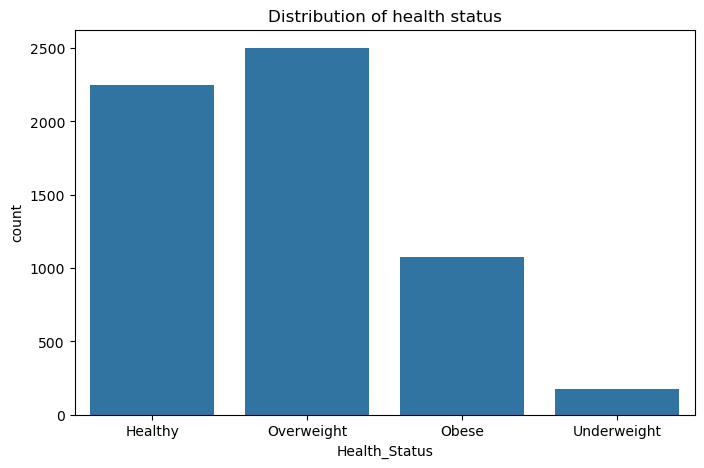

In [19]:
# Targer Variable Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Health_Status',data=df)
plt.title('Distribution of health status')
plt.show()


The datasset  contains  major 4 healthy status which are 'Healthy', 'Overweight',' Obese' and 'Underweight'.

The Healthy and Overweight individuals are majority observations and Underweight category individuals are less.

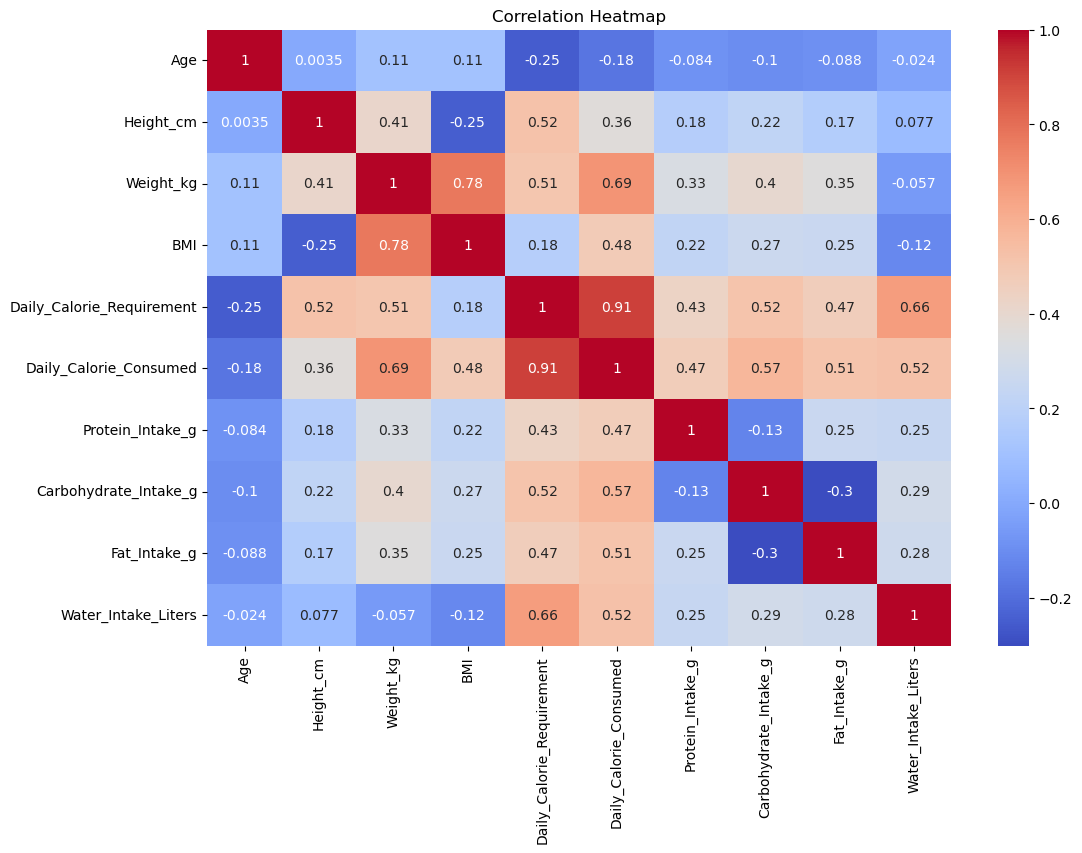

In [20]:
#Correlation analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()

Weight and BMI are expected to show a strong positive correlation.

Daily calorie consumed with BMI and weight is also showing strong relationship.

Water intake and activity level may show weaker relationships with obesity-related metrics.

# 4. Exploratory Data analysis

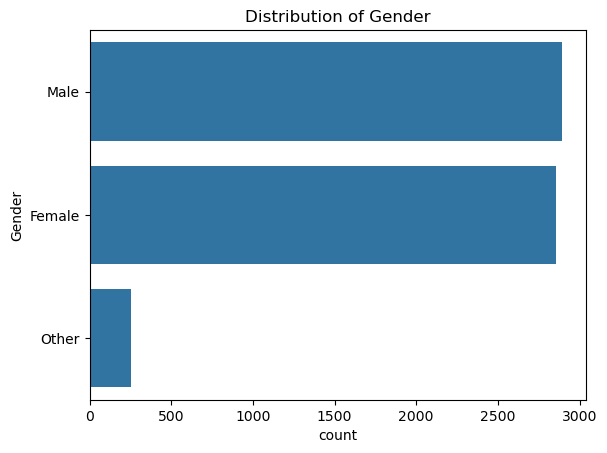

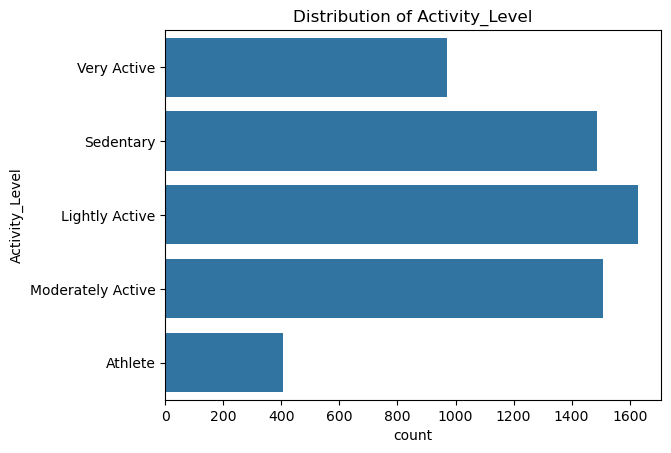

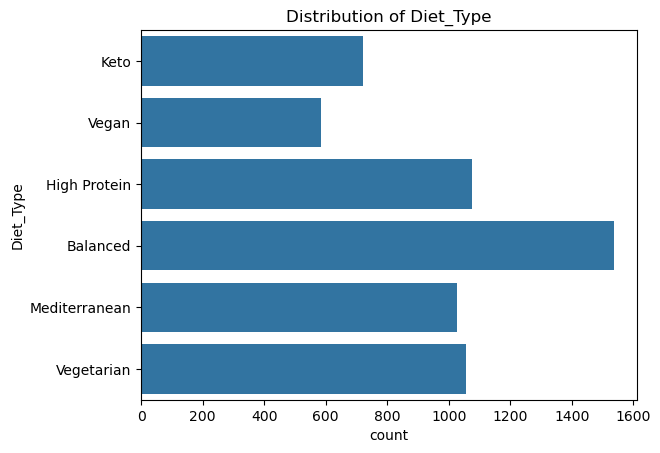

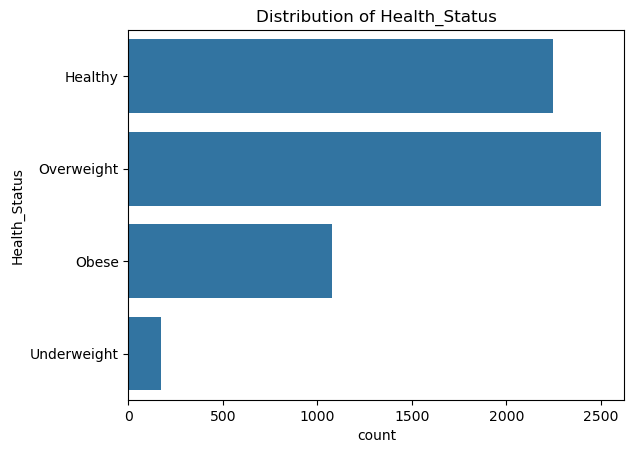

In [33]:
cat_cols=df.select_dtypes(include='object').columns
cat_cols=cat_cols.drop('Person_ID')

for col in cat_cols:
    sns.countplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

1. Gender => 3 category genders are present here. Male and Female categories are mostly seeing and appears balanced.
2. Activity level => Athelets are very less. Sedentary and Moderately active persons are equal. Very active persons are less compared to sedentary persons and Lightly active persons are mostly higher.
3. The Vegan diet type folllowing persons are less. Mostly common diet type is Balanced.
4. The most health status of the persons are Overweight . Less is Under weight.

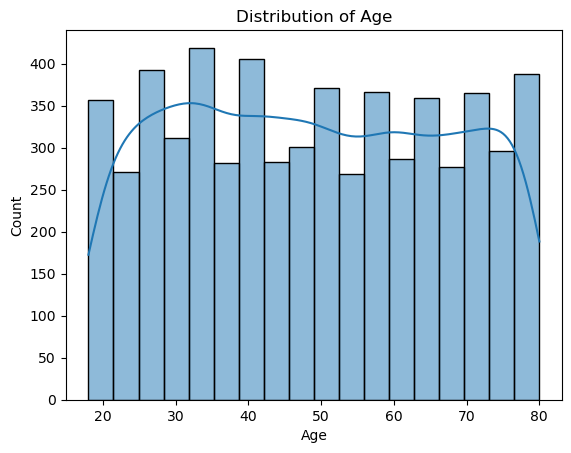

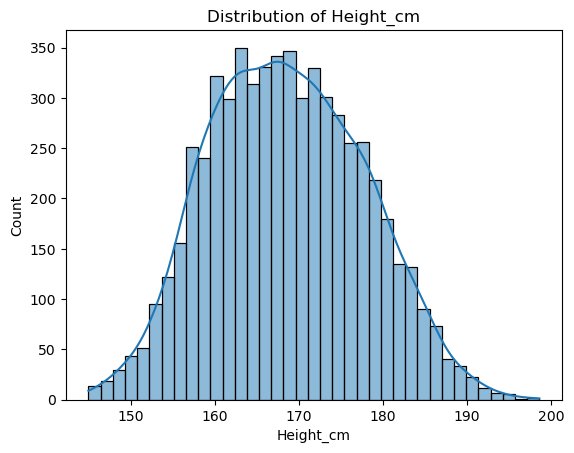

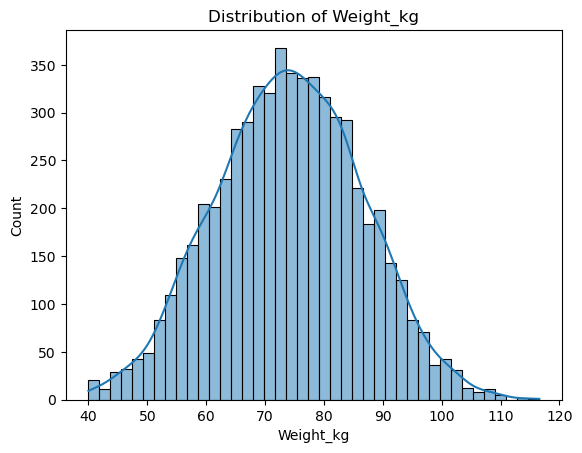

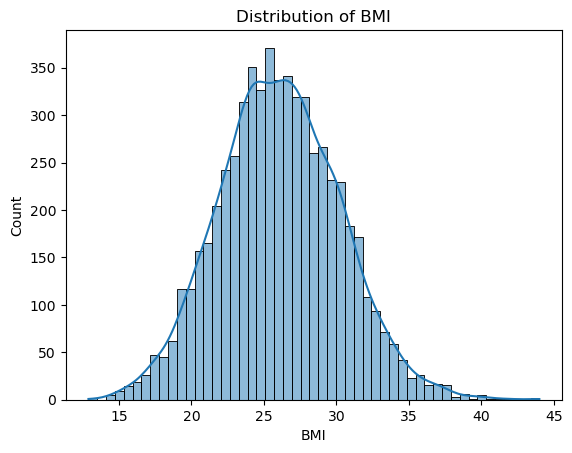

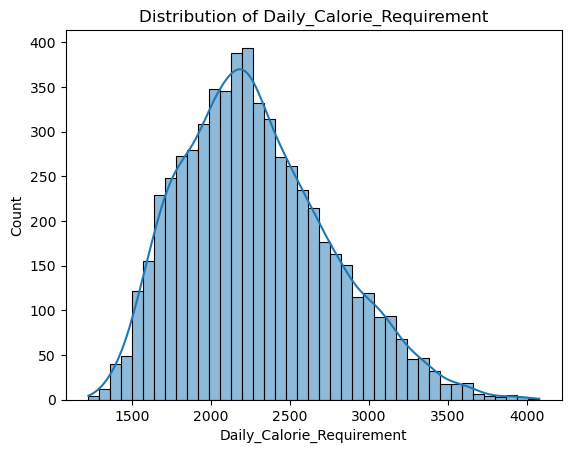

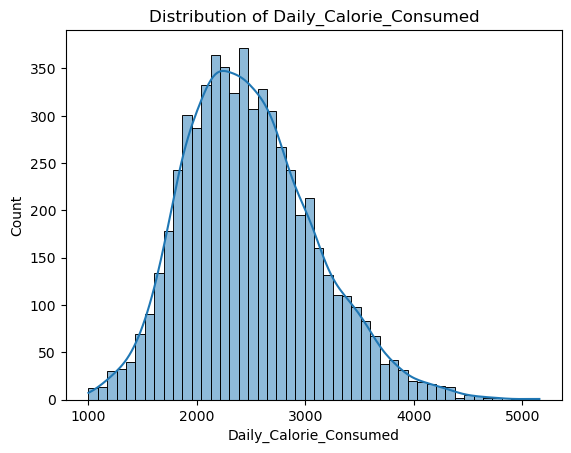

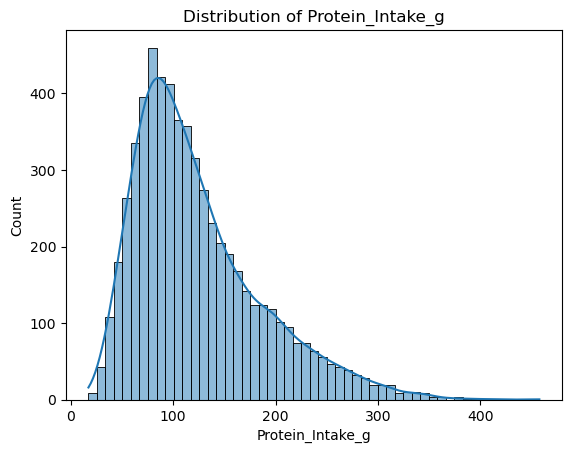

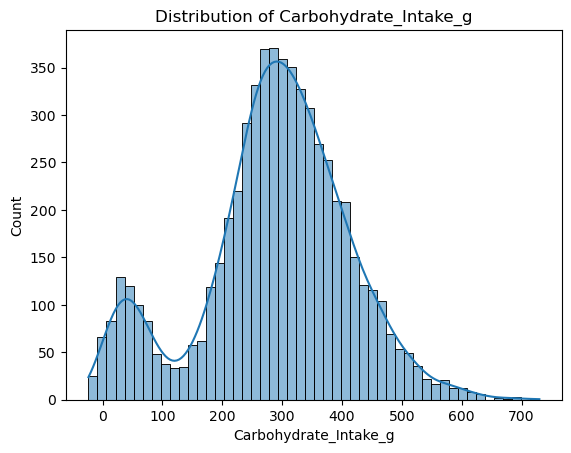

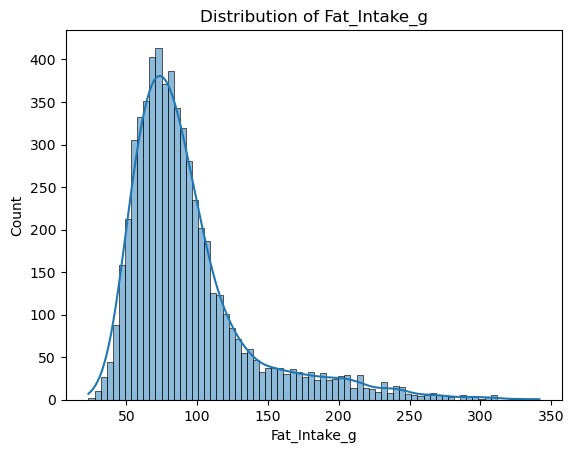

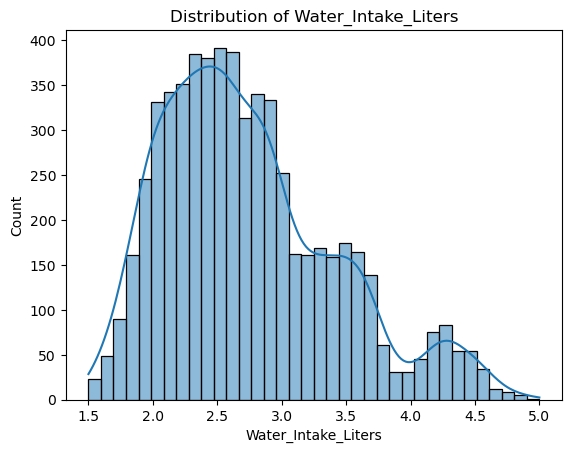

In [36]:
num_cols= df.select_dtypes(include=['int64','float64'])
for col in num_cols:
    sns.histplot(df[col],kde= True)
    plt.title(f"Distribution of {col}")
    plt.show()

1. Age=> Dataset includes wide range of ages. Age range is 18-80. It may indirectly influence the health status.
2. Height => The height range is 145 to 199. and Most persons are in the range 160 to 180cm.
3. Weight =>Weight range is 40 to 117kg. Most persons are in the range of 60kg to 90kg.
4. BMI=> BMI is likely to be one of the strongest predictors of health status.
5. Daily_Calorie_Requirement => 2000 to 2500 calories are taken most people.
6. Daily_Calorie_Consumed => this and Daily_Calorie_Requirement are similiar. most of all persons are taking the same.
7. Protein_Intake_g => Its left skewed distributed data. and 50 to 150 range proteins taking the most persons.
8. Carbohydrate_Intake_g=>Around 200 to 400 calories taking the peoples.
9. 'Fat_Intake_g => comparatively 50 to 100 fat  taking the peoples
10. Water_Intake_Liters => daily 2 to 3 litre water is taking the people.

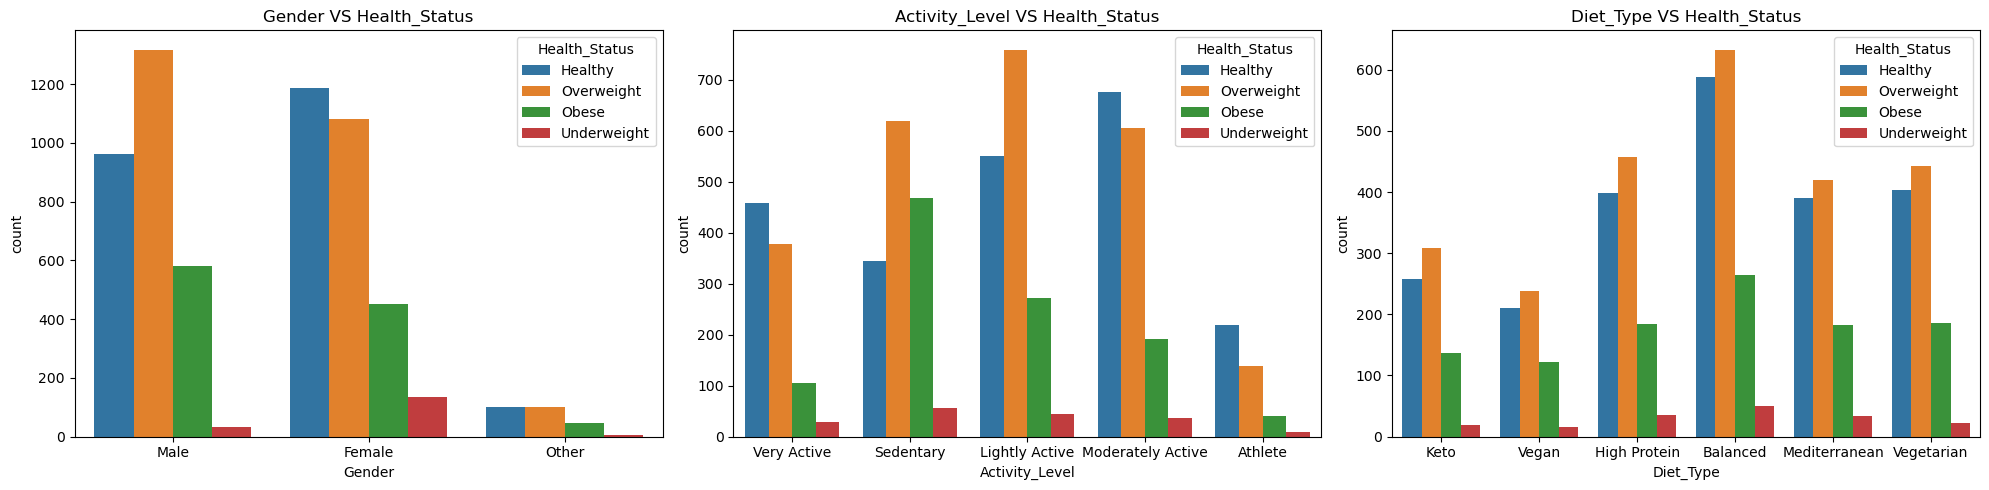

In [59]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols= cat_cols.drop(['Health_Status','Person_ID'])

plt.figure(figsize=(20,5))

for i, col in enumerate(cat_cols,1):
    plt.subplot(1,3,i)

    sns.countplot(x=col, hue='Health_Status',data=df)

    plt.title(f'{col} VS Health_Status')
plt.tight_layout()
plt.show()

Here we can see that in
1. Gender => Most male are  overweighted and In females most are healthy persons. That means compared to males, females are following proper diet and caring thier  health.In other gender most all health status are same.
2. Activity_Level=>In  Lightly active and sedentary persons, the overweighted persons higher than the healthy persons . In moderately and very actived perons, the healthy persons higher that the overweighted perosns.
3. Diet_Type => In the balanced diet type following perons, most persons are overweighted. In the graph we can see that, no matter which diet plan following for maintaing health status. Because in  most of all diet plans the overweighted persons are highervthat the other health status. The variation between healthy and overweight is less in the perosons follow the VEGAN, MEDITERRANEAN  diet types.


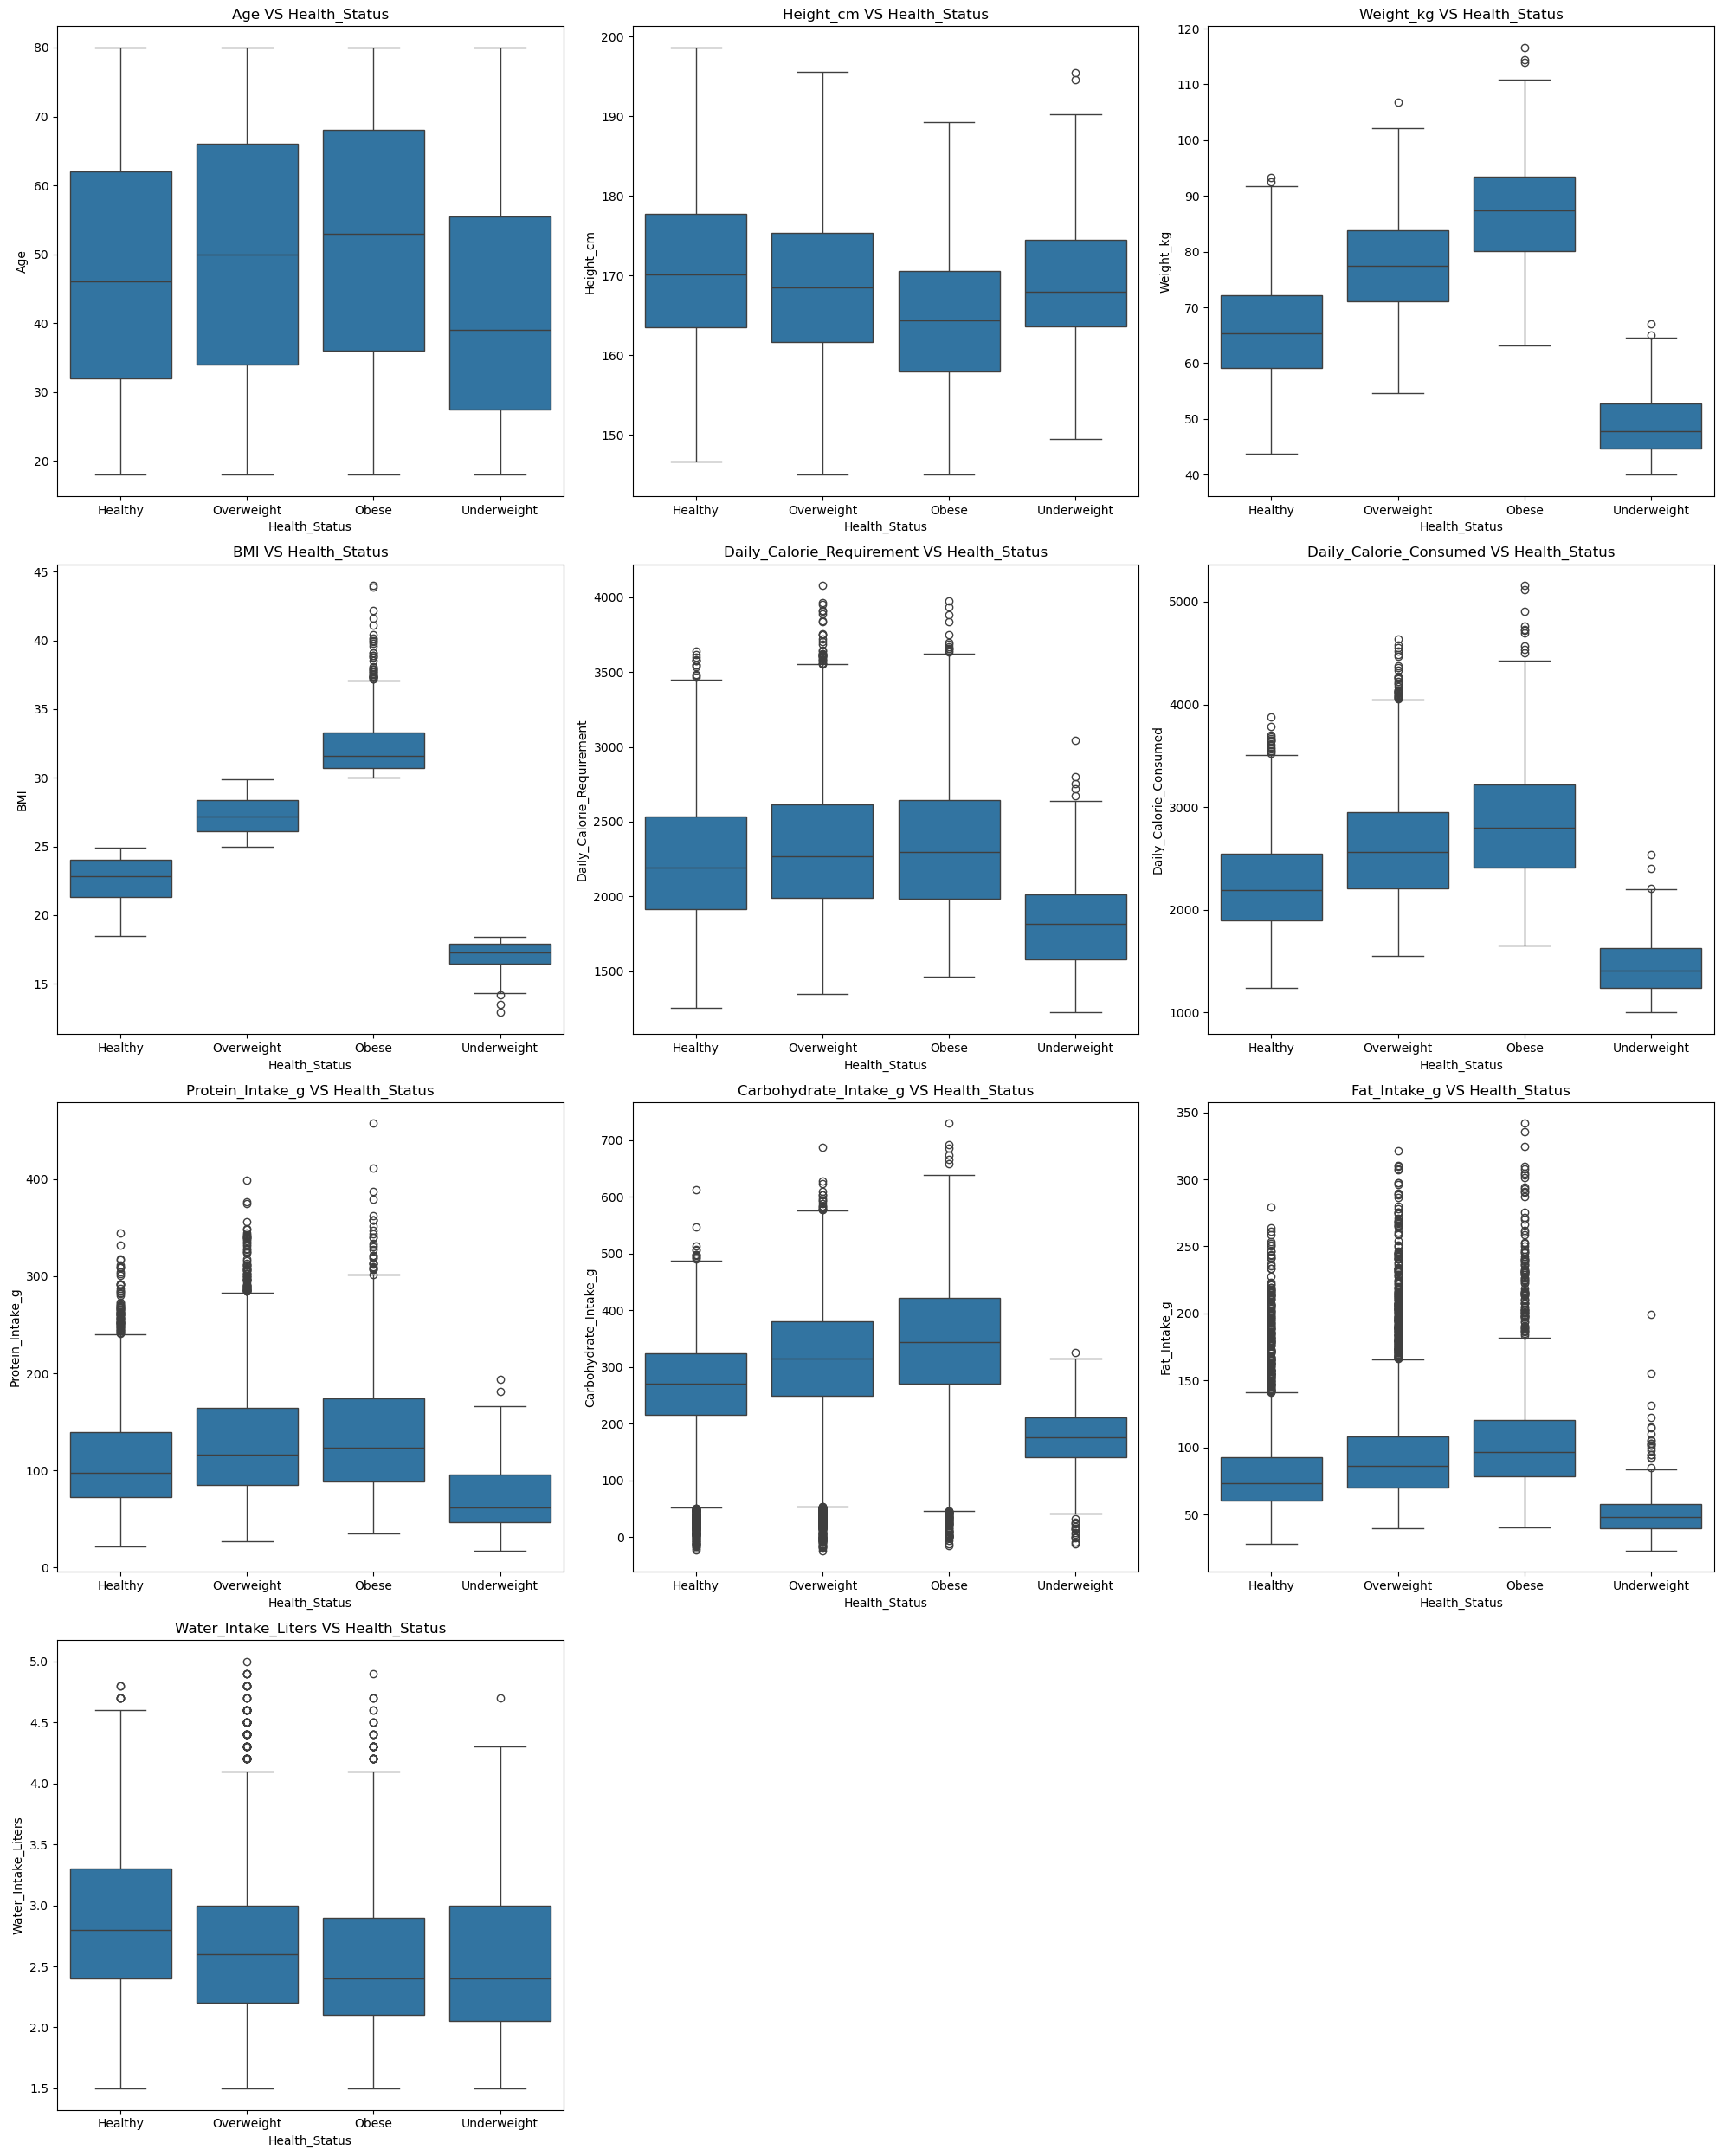

In [60]:
num_cols= df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(20,25))

for i,col in enumerate(num_cols,1):
    plt.subplot(4,3,i)

    sns.boxplot(x='Health_Status',y=col, data=df)
    plt.title(f'{col} VS Health_Status')

plt.tight_layout()
plt.show()

1. Age => Median age is slightly higher for Obese and Overweight individuals.Underweight individuals tend to be relatively younger.
2. Height_cm => Median height ranges between approximately 165–170 cm.Height distributions are very similar across all health groups.
3. Weight_kg => Obese individuals have the highest median weight.And Underweight individuals have the lowest median weight and Healthy individuals fall between underweight and overweight groups.
4. Underweight individuals have the lowest BMI.Overweight individuals have higher BMI.Obese individuals have the highest BMI.
5. Daily_Calorie_Requiremen => Underweight individuals have the lowest calorie requirements.
6. Daily_Calorie_Consumed => Obese individuals consume the highest calories.Underweight individuals consume the lowest calories.Several high-calorie outliers are present.
7. Protein_Intake_g => Obese individuals show higher median protein consumption.Many outliers are present.
8. Carbohydrate_Intake_g => Obese individuals generally consume more carbohydrates. Underweight individuals consume fewer carbohydrates.Some unusual low or negative values appear as outliers.
9. Fat_Intake_g => Numerous high-fat intake outliers are observed.Obese individuals have the highest median fat intake. Underweight individuals have the lowest fat intake.
10. Water_Intake_Liters => Some Outliers are present. Healthy individuals are taking higher litres of wawter and obese and underweights are taking less water

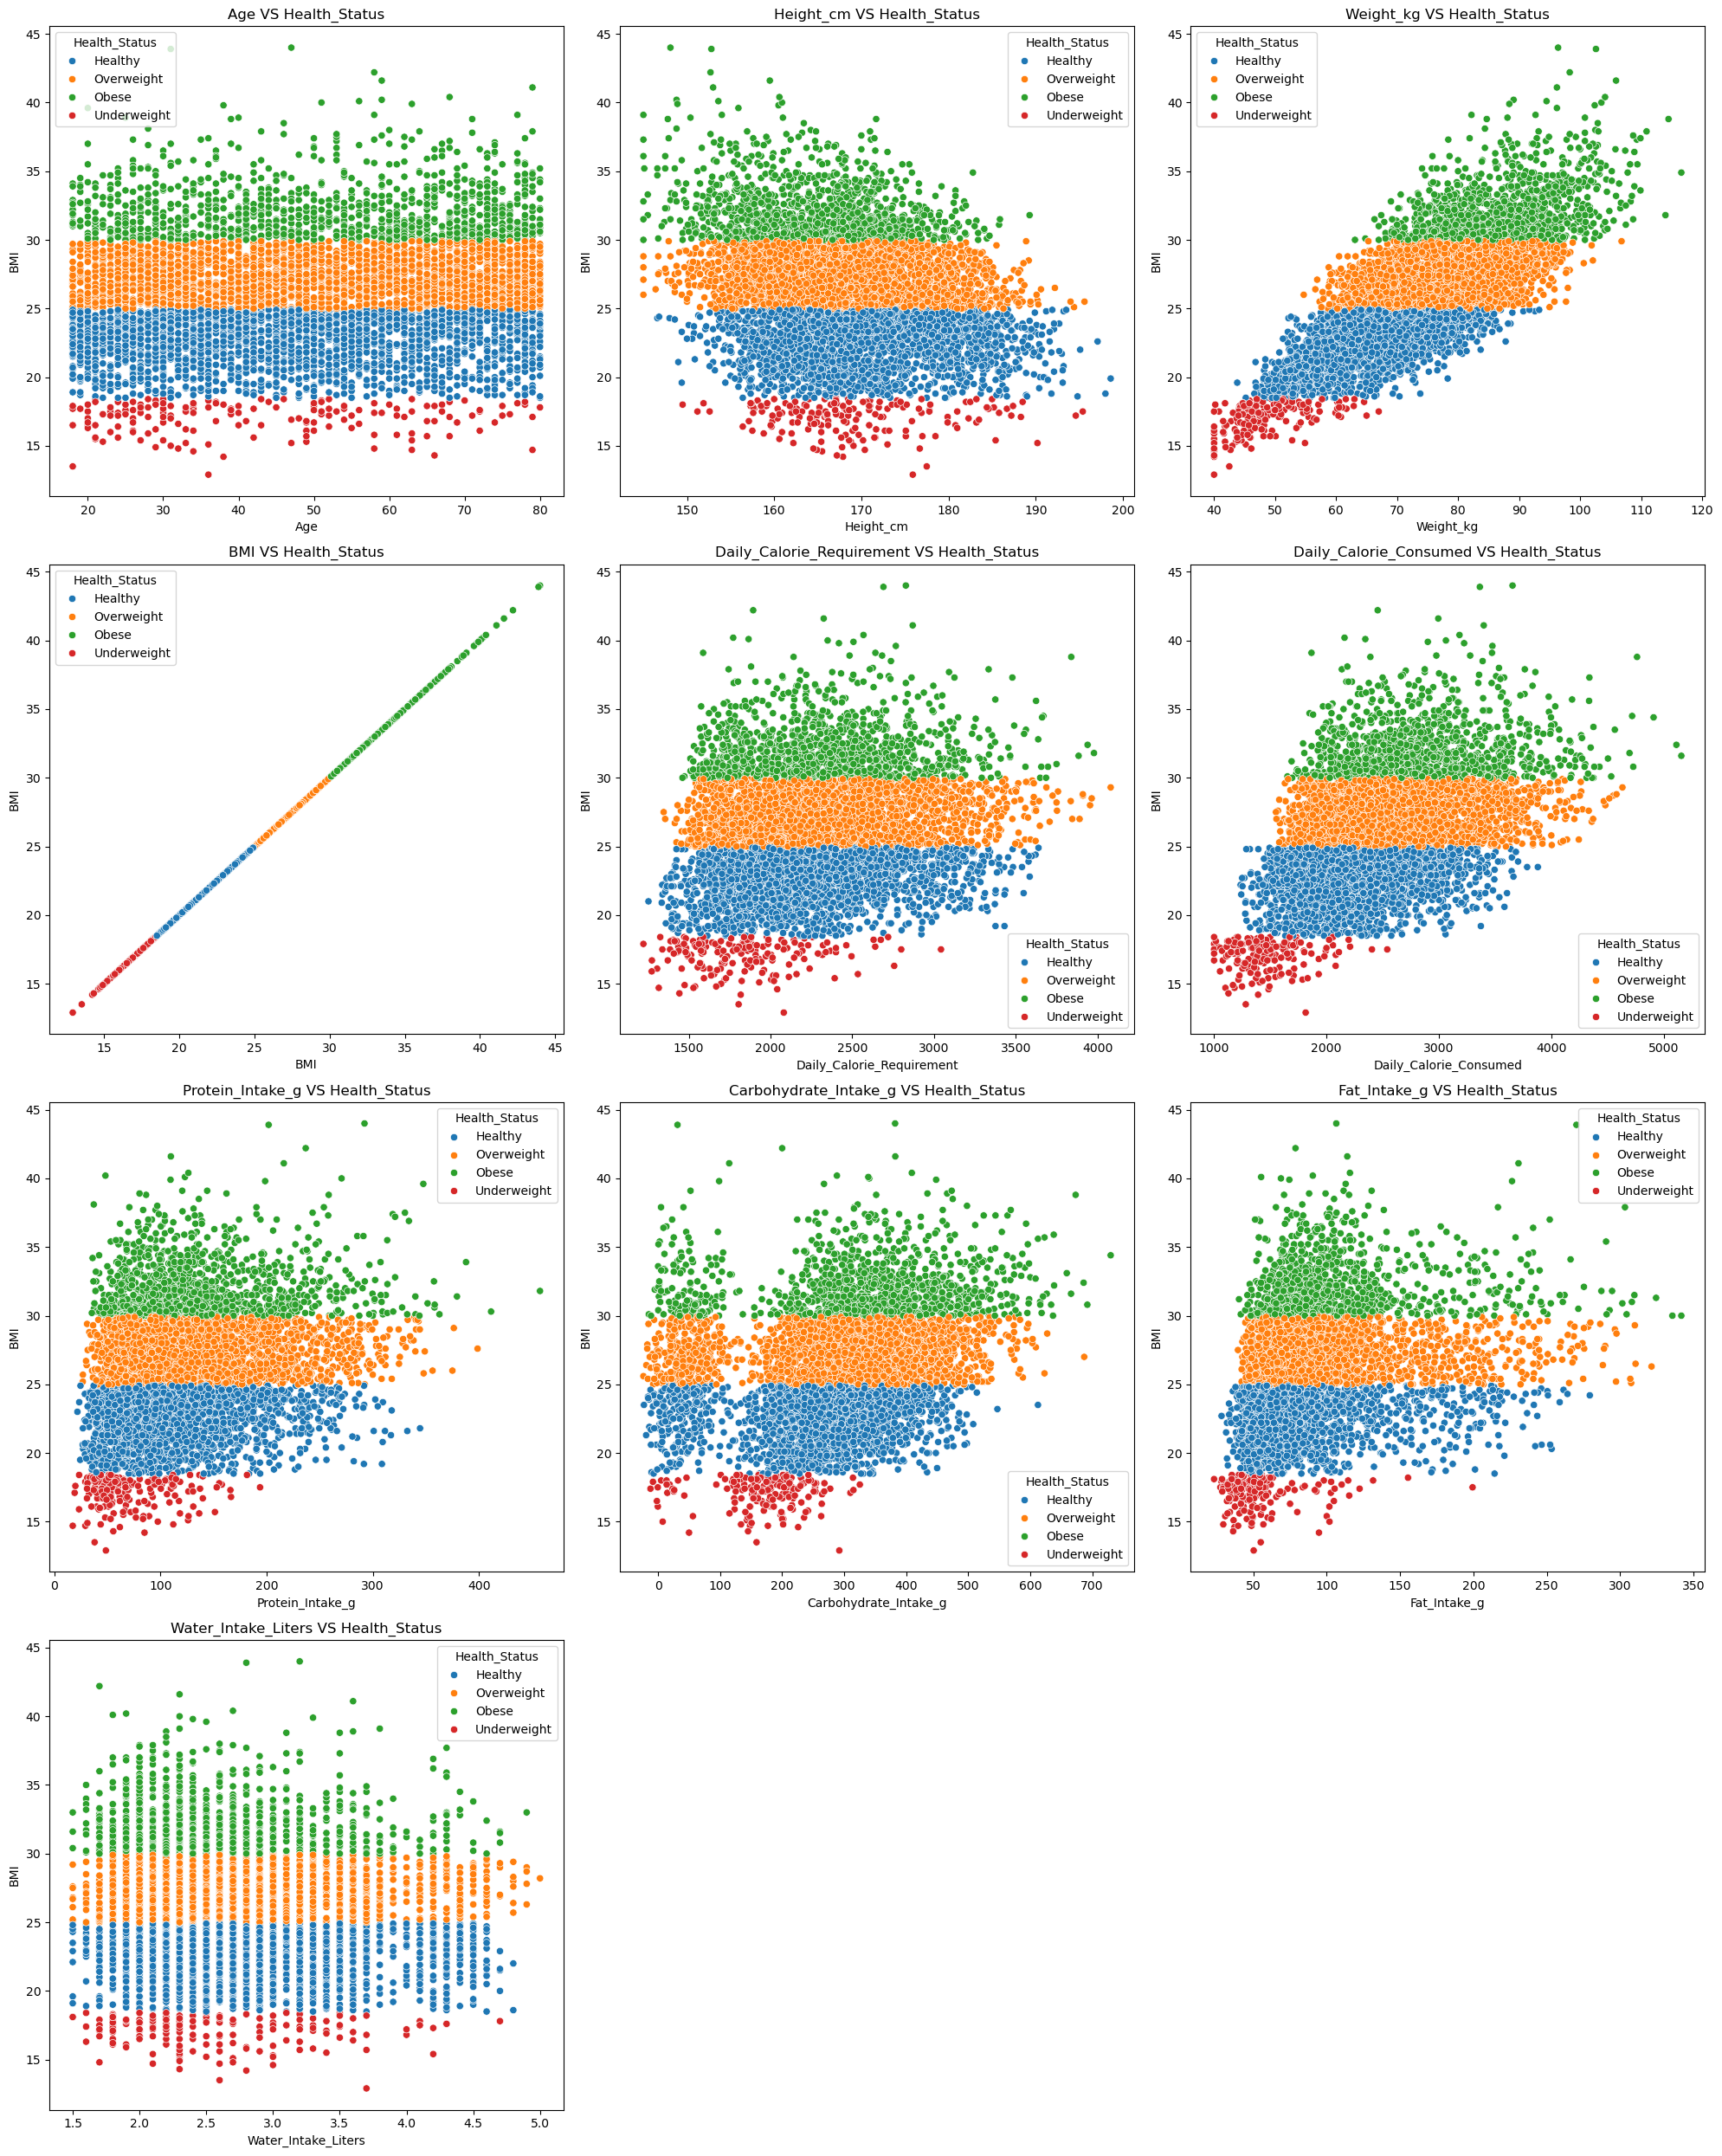

In [66]:
num_cols= df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(20,25))

for i,col in enumerate(num_cols,1):
    plt.subplot(4,3,i)

    sns.scatterplot(y='BMI',x=col, data=df,hue='Health_Status')
    plt.title(f'{col} VS Health_Status')

plt.tight_layout()
plt.show()

# 5. Data cleaning and Preprocessing

In [88]:
#Dropping the unwanted column
df=df.drop('Person_ID',axis=1)
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,45,Female,161.1,79.1,30.5,Lightly Active,2039,2296,85.0,305.9,81.4,2.4,Balanced,Obese
5996,53,Female,157.7,63.7,25.6,Sedentary,1555,1851,177.0,179.7,47.1,1.8,High Protein,Overweight
5997,43,Female,154.0,81.8,34.5,Athlete,2840,3601,139.7,483.3,123.2,4.4,Mediterranean,Obese
5998,51,Female,162.8,77.8,29.4,Lightly Active,1994,2126,118.7,51.9,160.4,2.8,Keto,Overweight


In [89]:
#Encoding
# Check Unique Values
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}")
    print(df[col].unique())


Gender
['Male' 'Female' 'Other']

Activity_Level
['Very Active' 'Sedentary' 'Lightly Active' 'Moderately Active' 'Athlete']

Diet_Type
['Keto' 'Vegan' 'High Protein' 'Balanced' 'Mediterranean' 'Vegetarian']

Health_Status
['Healthy' 'Overweight' 'Obese' 'Underweight']


**Labe Encoding**

In [90]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()

In [91]:
for col in cat_cols:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    
    print(f"\n{col}")
    
    mapping = dict(zip(le.classes_,
                       le.transform(le.classes_)))
    
    print(mapping)


Gender
{'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}

Activity_Level
{'Athlete': np.int64(0), 'Lightly Active': np.int64(1), 'Moderately Active': np.int64(2), 'Sedentary': np.int64(3), 'Very Active': np.int64(4)}

Diet_Type
{'Balanced': np.int64(0), 'High Protein': np.int64(1), 'Keto': np.int64(2), 'Mediterranean': np.int64(3), 'Vegan': np.int64(4), 'Vegetarian': np.int64(5)}

Health_Status
{'Healthy': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2), 'Underweight': np.int64(3)}


In [92]:
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,50,1,176.4,74.8,24.0,4,2852,2625,183.0,16.9,202.8,3.3,2,0
1,18,0,167.6,75.5,26.9,3,1904,2044,90.1,306.5,50.8,1.9,4,2
2,68,0,161.9,87.2,33.3,1,2009,2540,222.7,281.3,58.2,2.4,1,1
3,22,0,169.3,66.9,23.3,2,2318,2096,69.5,299.8,68.7,2.9,0,0
4,30,1,179.1,75.3,23.5,3,2144,1937,32.9,285.6,73.7,2.2,0,0


We are done Label encoding here. Because of Random Forest is a tree-based algorithm.label encoding usually works well with tree-based models.If we done onehot encoding method we get more columns and It will be complicated.

***Outliers Treatment***
Boxplot analysis reveals the presence of outliers in the dataset . especially in BMI,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Carbohydrate_Intake_g and Carbohydrate_Intake_g.But random forest is a tree based algorithm and is generally robust to outliers. If we treated the outliers there is a chance to remove the important data of this dataset. It may effect the accuracy and model efficiecncy of the data set.

In [93]:
#We need to treate the impossible values in the dataset.In carbo_hydrate_intake_g have -ve values. It is impossible. So we need to treate the values.
df[df['Carbohydrate_Intake_g'] < 0]

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
55,67,0,163.0,71.1,26.8,2,2046,2323,167.6,-6.0,186.3,3.0,2,2
166,23,1,175.9,78.2,25.3,1,2543,3022,209.9,-8.6,246.3,2.5,2,2
178,37,0,159.1,66.9,26.4,4,2413,2688,191.3,-18.9,222.0,3.8,2,2
259,67,1,177.2,82.2,26.2,1,2282,2551,179.4,-3.5,205.3,2.8,2,2
278,19,0,153.0,65.5,28.0,1,1987,2258,145.1,-3.2,187.8,2.7,2,2
321,30,0,157.1,67.2,27.2,2,2210,2507,177.5,-8.9,203.6,2.7,2,2
462,59,0,156.5,67.4,27.5,2,2015,2347,162.2,-1.3,189.3,2.8,2,2
541,27,0,171.2,79.8,27.2,1,2199,2609,187.3,-9.0,210.6,2.4,2,2
760,56,1,179.1,96.4,30.1,3,2306,3051,214.3,-14.9,250.4,2.3,2,1
824,49,0,172.7,48.0,16.1,3,1457,1291,94.2,-0.3,101.8,1.9,2,3


In [99]:
med_carb= df['Carbohydrate_Intake_g'].median()

df.loc[df['Carbohydrate_Intake_g']<0,'Carbohydrate_Intake_g']=med_carb


In [100]:
df[df['Carbohydrate_Intake_g'] < 0]

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status


Now we are replace the -ve values of Carbohydrate_Intake_g with median of Carbohydrate_Intake_g. The median value of the feature was used for replacement because the distribution contained outliers and the median is less sensitive to extreme values than the mean.

In [98]:
med_carb= df['Carbohydrate_Intake_g'].median()
med_carb

297.15

In [110]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,50,1,176.4,74.8,24.0,4,2852,2625,183.0,16.9,202.8,3.3,2,0
1,18,0,167.6,75.5,26.9,3,1904,2044,90.1,306.5,50.8,1.9,4,2
2,68,0,161.9,87.2,33.3,1,2009,2540,222.7,281.3,58.2,2.4,1,1
3,22,0,169.3,66.9,23.3,2,2318,2096,69.5,299.8,68.7,2.9,0,0
4,30,1,179.1,75.3,23.5,3,2144,1937,32.9,285.6,73.7,2.2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,45,0,161.1,79.1,30.5,1,2039,2296,85.0,305.9,81.4,2.4,0,1
5996,53,0,157.7,63.7,25.6,3,1555,1851,177.0,179.7,47.1,1.8,1,2
5997,43,0,154.0,81.8,34.5,0,2840,3601,139.7,483.3,123.2,4.4,3,1
5998,51,0,162.8,77.8,29.4,1,1994,2126,118.7,51.9,160.4,2.8,2,2


# 6. Feature Selection

In [102]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed',
       'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g',
       'Water_Intake_Liters', 'Diet_Type', 'Health_Status'],
      dtype='object')

In [107]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [108]:
X

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type
0,50,1,176.4,74.8,24.0,4,2852,2625,183.0,16.9,202.8,3.3,2
1,18,0,167.6,75.5,26.9,3,1904,2044,90.1,306.5,50.8,1.9,4
2,68,0,161.9,87.2,33.3,1,2009,2540,222.7,281.3,58.2,2.4,1
3,22,0,169.3,66.9,23.3,2,2318,2096,69.5,299.8,68.7,2.9,0
4,30,1,179.1,75.3,23.5,3,2144,1937,32.9,285.6,73.7,2.2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,45,0,161.1,79.1,30.5,1,2039,2296,85.0,305.9,81.4,2.4,0
5996,53,0,157.7,63.7,25.6,3,1555,1851,177.0,179.7,47.1,1.8,1
5997,43,0,154.0,81.8,34.5,0,2840,3601,139.7,483.3,123.2,4.4,3
5998,51,0,162.8,77.8,29.4,1,1994,2126,118.7,51.9,160.4,2.8,2


In [109]:
y

0       0
1       2
2       1
3       0
4       0
       ..
5995    1
5996    2
5997    1
5998    2
5999    2
Name: Health_Status, Length: 6000, dtype: int64

In [111]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

The dataset was divided into 70% training data and 30% testing data. The 70% portion was used to train the Random Forest model, while the remaining 30% was reserved for evaluating the model's performance on unseen data.The dataset contains approximately 6000 records, making an 70:30 split suitable for achieving a balance between learning and testing.

In [113]:
print("X_train shape:", x_train.shape)  
print("X_test shape:", x_test.shape)    
print("y_train shape:", y_train.shape)  
print("y_test shape:", y_test.shape)

X_train shape: (4200, 13)
X_test shape: (1800, 13)
y_train shape: (4200,)
y_test shape: (1800,)


**Scaling**
Here we are not doing the scailing techinique because RF if a tree based algorithm and that uses feature thresholds to split the data. Therefore, difference in feature scales do not significantly affect model performance.

# 7. Model Building

In [118]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

**Hyperparameters**

*n_estimators* --> Number of decision trees in the forest.The n_estimators parameter specifies the number of trees in the Random Forest. Increasing the number of trees generally improves model stability and accuracy but increases computational cost.

*max_depth* --> Maximum depth of each tree -The max_depth parameter controls how deep each decision tree can grow. Limiting tree depth helps prevent overfitting and improves model generalization.

*min_samples_split* --> Minimum number of samples required to split a node.The min_samples_split parameter specifies the minimum number of samples required before a node can be split. Larger values reduce model complexity and help avoid overfitting.

*min_samples_leaf* --> inimum number of observations allowed in a leaf node.The min_samples_leaf parameter defines the minimum number of observations required in a terminal leaf node. Increasing this value can improve model generalization.

*max_features* -->Number of features randomly selected when searching for the best split.The max_features parameter determines how many features are randomly considered at each split. This randomness improves diversity among trees and enhances overall model performance.

*random_state* -->Controls randomness. The random_state parameter ensures reproducibility by fixing the random seed. Using the same random state produces consistent results across multiple runs.


# 8. Model Evaluation

In [121]:
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy of Random Forest Classifier : {accuracy:.4f}")

Accuracy of Random Forest Classifier : 1.0000


In [123]:
precision= precision_score(y_test,y_pred,average='weighted')
print("Precision:", precision)

Precision: 1.0


In [125]:
recall= recall_score(y_test,y_pred,average='weighted')
print("Recall:", recall)

Recall: 1.0


In [126]:
f1=f1_score(y_test,y_pred,average= 'weighted')
print("F1 Score:", f1)

F1 Score: 1.0


In [130]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       663
           1       1.00      1.00      1.00       309
           2       1.00      1.00      1.00       777
           3       1.00      1.00      1.00        51

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



Here, 

Healthy =0 

Obese= 1 

Overweight= 2 

underweight=3

In [133]:
#Confusion Metrics

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[663   0   0   0]
 [  0 309   0   0]
 [  0   0 777   0]
 [  0   0   0  51]]


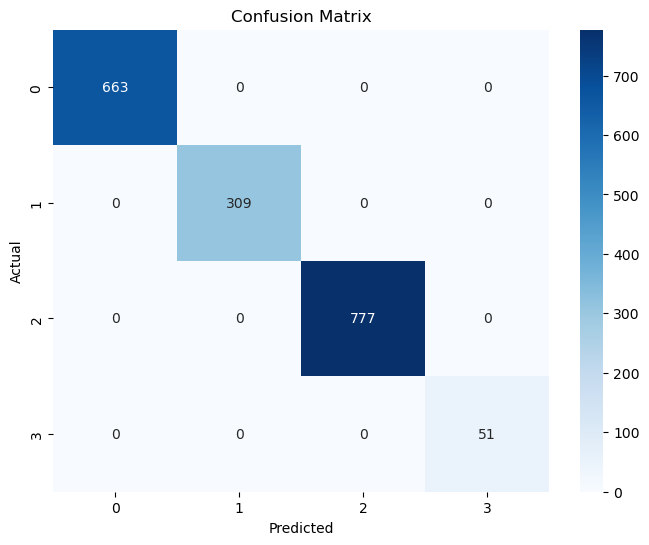

In [136]:
#Confusion Matrix Visualization
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

The confusion matrix shows the number of correctly and incorrectly classified observations for each health status category. Higher values along the diagonal indicate better model performance.

In [137]:
#ROC curve

y_prob=rf.predict_proba

# 9. Feature Importance

In [138]:
feature_importance= rf.feature_importances_

In [141]:
importance_df=pd.DataFrame({'Feature': X.columns, 'Importance' : feature_importance})
importance_df= importance_df.sort_values(by='Importance',ascending=False)
print(importance_df)

                      Feature  Importance
4                         BMI    0.640829
3                   Weight_kg    0.141295
2                   Height_cm    0.070535
7      Daily_Calorie_Consumed    0.049473
6   Daily_Calorie_Requirement    0.021992
9       Carbohydrate_Intake_g    0.017540
10               Fat_Intake_g    0.014405
11        Water_Intake_Liters    0.012920
8            Protein_Intake_g    0.009902
5              Activity_Level    0.006720
1                      Gender    0.006708
0                         Age    0.006019
12                  Diet_Type    0.001662


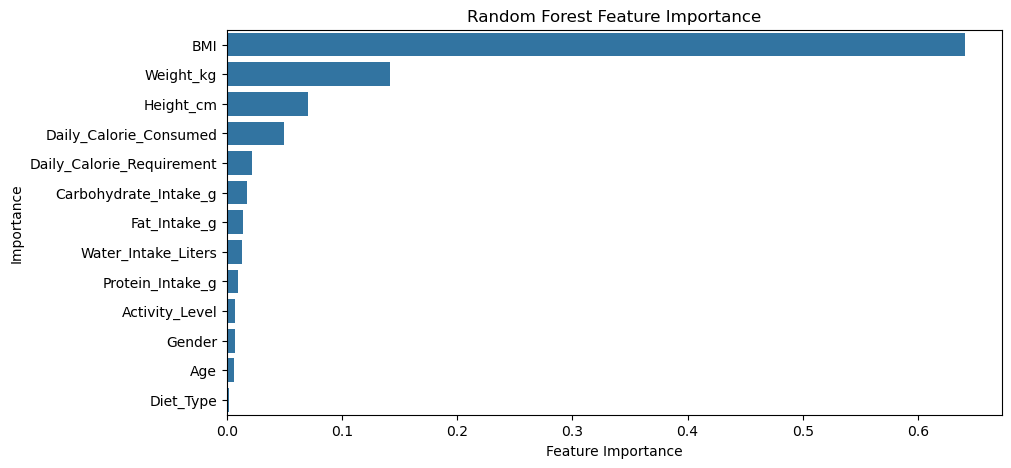

In [147]:
#ploting
plt.figure(figsize=(10,5))
sns.barplot(data=importance_df,x='Importance',y='Feature')
plt.xlabel('Feature Importance')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

Feature importance indicated that the BMI  is the most important and influential  predictor of Health status.It contributes approximately 64% of the total importance. weight, height , daily calorie are the next important features, But it is less than the BMI. Their total contribution is around 26% of the total.Nutritional intake variables such as protein, carbohydrate, fat, and water intake had relatively smaller contributions.These findings suggest that body composition indicators, particularly BMI, play the most critical role in determining an individual's health status.

# 10. Hyper Parameter Tuning

In [150]:
#Hyperparameter Tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid={ 
    'n_estimators':[100,200,300],
    'max_depth' :[None,5,10,15],
    'min_samples_split' :[2,5,10],
    'min_samples_leaf' :[1,2,4],
    'max_features' : ['sqrt','log2',None]
}
    
grid_search = GridSearchCV ( estimator= RandomForestClassifier(random_state=42),
                            param_grid=param_grid,
                            cv=5,
                            scoring='accuracy',
                            n_jobs=-1
                           )

grid_search.fit(x_train,y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 15],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

We have two options to do the hyperparameter tuning. one is GridSearchCV and other one is RandomizedSearchCV. Here we are doing GridSearch CV. Because of dataset contains around 6000 reccords which is manageble and small to medium range dataset.GridSearchCV was selected because the dataset size was manageable and the number of hyperparameters was relatively small. Unlike RandomizedSearchCV, which evaluates only a subset of parameter combinations, GridSearchCV performs an exhaustive search and ensures that the best combination within the defined grid is identified.

In [151]:
#Best Parameters

print("Best Parameters: ")

print(grid_search.best_params_)

Best Parameters: 
{'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [152]:
#Best Score
print("Best CV Score : ")

print(grid_search.best_score_)

Best CV Score : 
1.0


In [153]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(x_test)

In [154]:
 accuracy_score(y_test, y_pred_tuned)

1.0

# 11. Compare Before vs After Tuning

In [155]:
from sklearn.metrics import accuracy_score

print("Before Tuning:",
      accuracy_score(y_test, y_pred))

print("After Tuning:",
      accuracy_score(y_test, y_pred_tuned))

Before Tuning: 1.0
After Tuning: 1.0


# 12. Conclusion 

A Random Forest Classification model was developed to predict an individuals health  status  based on the demographic, dietry,  and lifestyle - related afeatures. The dataset was preprocessd by handling invalued values(There are some -ve values. replaced by median), encoded categorical variables and EDA. The model was trained by 70: 30  train-test split and evaluated by using  classification metrics including accuracy score,precision , recall and f1 scores and also used Confusion metrics to confirm there is no mis-predicted values are present. And then performed the Hyper parameter tuning by using GridSearcCV to identify the best combination of the parameters and improve the model.

#### Key Findings:

From EDA and feature importance we can under stood that,
1. BMI is  the most influential feature of Health status. It contributed approximately 64% of the total feature importance.
2. Weight and Height are the next important features of predicting health status of an individual.
3. Daily_Calorie_Consumed showed a significant impact on health classification, suggesting that calorie intake plays a major role in determining weight-related health outcomes.
4. Features such as Diet_Type, Gender, and Age showed relatively low importance, indicating that health status in this dataset is driven more by measurable physical and dietary indicators than by demographic characteristics.

#### Business Recomendations:

Based on the findings of RF model,

1. Focus on BMI
2. Daily calorie consumption  was one of the most infuential factors. It will helps to maintain healthy body weight and it leas to good health status.
3. Personalized diet recommendations can help individuals achieve healthier lifestyles.
